# Fairlearn

This notebook walks through deckard's Fairlearn integration for both sklearn and PyTorch workflows, and includes attribute-inference attacks to illustrate privacy risk.

## Navigation

1. Environment and imports
2. Fairlearn-native dataset loading (Adult)
3. FairlearnDataConfig with preprocessing defense
4. sklearn fairness defense (`ExponentiatedGradient`)
5. Attribute-inference attack on sensitive feature
6. PyTorch fairness defense (`AdversarialFairnessClassifier`)
7. Yellowbrick plotter (sklearn fairness experiment)
8. Seaborn summary plots

The dataset source in this notebook is `fairlearn.datasets`, similar to how lifelines-native datasets are used in the survival notebook.

## 1. Environment and Imports

Install optional dependencies before running:

```bash
pip install -e .[fairlearn,seaborn,yellowbrick,torch]
```

In [30]:
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch

from deckard.data import DataConfig
from deckard.data.fairness import FairlearnDataConfig
from deckard.model.fairness import FairlearnModelConfig, FairlearnPytorchModelConfig
from deckard.model.defend import DefensePipelineConfig
from deckard.attack import AttackConfig
from deckard.experiment import ExperimentConfig
from deckard.file import FileConfig
from deckard.plot.yellowbrick_plots import YellowbrickPlotConfig
from deckard.plot.seaborn_plots import SeabornPlotConfig, SeabornPlotConfigList

NOTEBOOK_ROOT = Path(".")
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "fairlearn_artifacts"
PLOT_DIR = ARTIFACT_DIR / "plots"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (8, 5)

print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Torch version: {torch.__version__}")

Artifact directory: ~/Documents/deckard/notebooks/build/fairlearn_artifacts
Torch version: 2.11.0


## 2. Adult Dataset Loading

This section uses deckard's built-in `adult` loader, which now performs the Adult target encoding, sensitive-feature encoding, and categorical expansion centrally in `DataConfig`.

In [31]:
adult_data = DataConfig(
    dataset_name="adult",
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    classifier=True,
)
adult_data._load_data()
adult_frame = adult_data.X.copy()

target_series = adult_data.y.copy()

print("Rows/cols:", adult_frame.shape)
print("Sensitive feature candidate counts:")
print(adult_frame["sex"].value_counts(dropna=False).sort_index())
print("Target counts:")
print(target_series.value_counts(dropna=False).sort_index())
print("Numeric frame:", all(pd.api.types.is_numeric_dtype(dtype) for dtype in adult_frame.dtypes))
adult_frame.head()

Rows/cols: (48842, 97)
Sensitive feature candidate counts:
sex
0    32650
1    16192
Name: count, dtype: int64
Target counts:
class
0    37155
1    11687
Name: count, dtype: int64
Numeric frame: True


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,...,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,sex
0,25,226802,7,0,0,40,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
1,38,89814,9,0,0,50,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
2,28,336951,12,0,0,40,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
3,44,160323,10,7688,0,40,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,0
4,18,103497,10,0,0,30,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,1


## 3. FairlearnDataConfig with Preprocessing Defense

`FairlearnDataConfig` can inject a Fairlearn preprocessing defense (`CorrelationRemover`) while preserving sensitive-feature caches for fairness and attack scoring.

In [32]:
fair_data = FairlearnDataConfig(
    dataset_name="adult",
    classifier=True,
    stratify=False,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    sensitive_columns=["sex"],
    fairness_defense={
        "step_name": "fairness_correlation_remover",
        "name": "fairlearn.preprocessing.CorrelationRemover",
        "alpha": 1.0,
    },
)

fair_data_scores = fair_data()

print("Train shape:", fair_data.X_train.shape)
print("Test shape:", fair_data.X_test.shape)
print("Sensitive train sample:", fair_data._sensitive_train.iloc[:5].tolist())
print("Fairness score keys:", list(fair_data_scores.keys()))

Train shape: (39073, 96)
Test shape: (9769, 96)
Sensitive train sample: ['0', '0', '0', '1', '0']
Fairness score keys: ['data_load_time', 'data_sample_time', 'pipeline_fit_time', 'pipeline_fit_n', 'pipeline_transform_time', 'pipeline_transform_n', 'fairness_scores']


## 4. sklearn Fairness Workflow on Defended Data

This section trains a sklearn model on the Fairlearn-defended Adult dataset from Section 3 and reports both utility and group-level accuracy gap metrics.

In [33]:
from sklearn.metrics import accuracy_score, precision_score

sk_fair_model = FairlearnModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 200},
    data=fair_data,
)

sk_fair_scores = sk_fair_model(fair_data)
sk_pred = np.asarray(sk_fair_model.predictions).reshape(-1)

sk_group_accuracies = {}
for group_value in sorted(fair_data._sensitive_test.unique().tolist()):
    mask = fair_data._sensitive_test == group_value
    sk_group_accuracies[f"group_{group_value}_accuracy"] = float(
        accuracy_score(fair_data.y_test.loc[mask], sk_pred[mask.to_numpy()]),
    )

sk_fair_scores.update(sk_group_accuracies)
if sk_group_accuracies:
    sk_fair_scores["sensitive_feature_accuracy_difference"] = float(
        max(sk_group_accuracies.values()) - min(sk_group_accuracies.values()),
    )
sk_fair_scores["precision"] = float(
    precision_score(fair_data.y_test, sk_pred, zero_division=0),
)

interesting_sk = [
    k for k in sorted(sk_fair_scores.keys())
    if "accuracy" in k or "sensitive_feature" in k or "precision" in k
]
print("sklearn fairness score keys:", interesting_sk[:20])
print({k: sk_fair_scores[k] for k in interesting_sk[:8] if isinstance(sk_fair_scores[k], (int, float))})

sklearn fairness score keys: ['accuracy', 'group_0_accuracy', 'group_1_accuracy', 'precision', 'sensitive_feature_accuracy_difference']
{'accuracy': 0.8109, 'group_0_accuracy': 0.773153125479957, 'group_1_accuracy': 0.8864333947206875, 'precision': 0.6485580147551978, 'sensitive_feature_accuracy_difference': 0.11328026924073054}


## 5. Sensitive Feature Recovery Benchmark

Because the Fairlearn preprocessing step removes `sex` from the transformed feature matrix, this section measures how recoverable that sensitive feature remains from the original Adult features using a simple black-box proxy classifier.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

attribute_X = adult_frame.drop(columns=["sex"]).copy()
attribute_y = adult_frame["sex"].astype(int).copy()

attr_X_train, attr_X_test, attr_y_train, attr_y_test = train_test_split(
    attribute_X,
    attribute_y,
    test_size=0.2,
    random_state=42,
    stratify=attribute_y,
)

attribute_proxy_model = LogisticRegression(max_iter=200)
attribute_proxy_model.fit(attr_X_train, attr_y_train)
attribute_pred = attribute_proxy_model.predict(attr_X_test)

attribute_scores = {
    "attribute_accuracy": float(accuracy_score(attr_y_test, attribute_pred)),
    "attribute_precision": float(precision_score(attr_y_test, attribute_pred, zero_division=0)),
    "attribute_recall": float(recall_score(attr_y_test, attribute_pred, zero_division=0)),
}
attribute_keys = sorted(attribute_scores.keys())

print("Attribute attack keys:", attribute_keys)
print("Attribute accuracy:", attribute_scores.get("attribute_accuracy"))
print("Attribute precision:", attribute_scores.get("attribute_precision"))
print("Attribute recall:", attribute_scores.get("attribute_recall"))

Attribute attack keys: ['attribute_accuracy', 'attribute_precision', 'attribute_recall']
Attribute accuracy: 0.7484901218139011
Attribute precision: 0.6195718654434251
Attribute recall: 0.6255016980549553


## 6. PyTorch Fairness Workflow

This section reuses the Fairlearn-preprocessed Adult dataset from Section 3 and fits a PyTorch model with fairness-aware group scoring. The Fairlearn defense here is the same `CorrelationRemover` preprocessing step, now evaluated through a torch model workflow.

In [35]:
from sklearn.metrics import accuracy_score

torch_X_train = fair_data.X_train
torch_X_test = fair_data.X_test
if hasattr(torch_X_train, "to_numpy"):
    torch_X_train = torch_X_train.to_numpy(dtype=np.float32)
else:
    torch_X_train = np.asarray(torch_X_train, dtype=np.float32)
if hasattr(torch_X_test, "to_numpy"):
    torch_X_test = torch_X_test.to_numpy(dtype=np.float32)
else:
    torch_X_test = np.asarray(torch_X_test, dtype=np.float32)

torch_y_train = fair_data.y_train.to_numpy(dtype=np.int64)
torch_y_test = fair_data.y_test.to_numpy(dtype=np.int64)
sensitive_train = fair_data._sensitive_train.reset_index(drop=True)
sensitive_test = fair_data._sensitive_test.reset_index(drop=True)

X_train_t = torch.tensor(torch_X_train, dtype=torch.float32)
X_test_t = torch.tensor(torch_X_test, dtype=torch.float32)
y_train_t = torch.tensor(torch_y_train, dtype=torch.long)
y_test_t = torch.tensor(torch_y_test, dtype=torch.long)

torch_fair_data = SimpleNamespace(
    X_train=X_train_t,
    y_train=y_train_t,
    X_test=X_test_t,
    y_test=y_test_t,
    _sensitive_train=sensitive_train,
    _sensitive_test=sensitive_test,
    _sensitive_all=pd.concat([sensitive_train, sensitive_test], ignore_index=True),
    classifier=True,
)

torch_fair_model = FairlearnPytorchModelConfig(
    model_type="torch.nn.Linear",
    model_params={"in_features": int(X_train_t.shape[1]), "out_features": 2},
    classifier=True,
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={"nb_epochs": 2, "batch_size": 128},
    data=torch_fair_data,
    device="cpu",
)

torch_fair_scores = torch_fair_model(torch_fair_data)
torch_pred_raw = torch_fair_model._predict(torch_fair_data.X_test)
torch_pred_labels = torch_pred_raw.argmax(dim=1).cpu().numpy()

group_accuracies = {}
for group_value in sorted(sensitive_test.unique().tolist()):
    mask = sensitive_test == group_value
    group_accuracies[f"group_{group_value}_accuracy"] = float(
        accuracy_score(torch_y_test[mask.to_numpy()], torch_pred_labels[mask.to_numpy()]),
    )

torch_fair_scores.update(group_accuracies)
if group_accuracies:
    torch_fair_scores["sensitive_feature_accuracy_difference"] = float(
        max(group_accuracies.values()) - min(group_accuracies.values()),
    )

interesting_torch = [
    k for k in sorted(torch_fair_scores.keys())
    if "accuracy" in k or "sensitive_feature" in k or "f1" in k
]
print("torch fairness score keys:", interesting_torch[:20])
print({k: torch_fair_scores[k] for k in interesting_torch[:8] if isinstance(torch_fair_scores[k], (int, float))})

torch fairness score keys: ['accuracy', 'f1', 'group_0_accuracy', 'group_1_accuracy', 'sensitive_feature_accuracy_difference']
{'accuracy': 0.2344, 'f1': 0.089, 'group_0_accuracy': 0.30056826908309014, 'group_1_accuracy': 0.10220994475138122, 'sensitive_feature_accuracy_difference': 0.1983583243317089}


## 7. Yellowbrick Plotter (sklearn fairness experiment)

Yellowbrick visualizers integrate with the composed sklearn fairness experiment for diagnostics like ROC AUC.

In [36]:
from sklearn.linear_model import LogisticRegression
from yellowbrick.classifier import ROCAUC

yb_path = (PLOT_DIR / "fairlearn_roc_auc.png").as_posix()
yb_model = LogisticRegression(max_iter=200)

yb_visualizer = ROCAUC(yb_model, classes=[0, 1])
yb_visualizer.fit(fair_data.X_train, fair_data.y_train)
yb_visualizer.score(fair_data.X_test, fair_data.y_test)
yb_visualizer.show(outpath=yb_path, clear_figure=True)

print("Yellowbrick plot written:", yb_path)

Yellowbrick plot written: ~/Documents/deckard/notebooks/build/fairlearn_artifacts/plots/fairlearn_roc_auc.png


<Figure size 800x500 with 0 Axes>

## 8. Seaborn Summary Plots

This section summarizes fairness and privacy-risk metrics from the sklearn and torch sections.

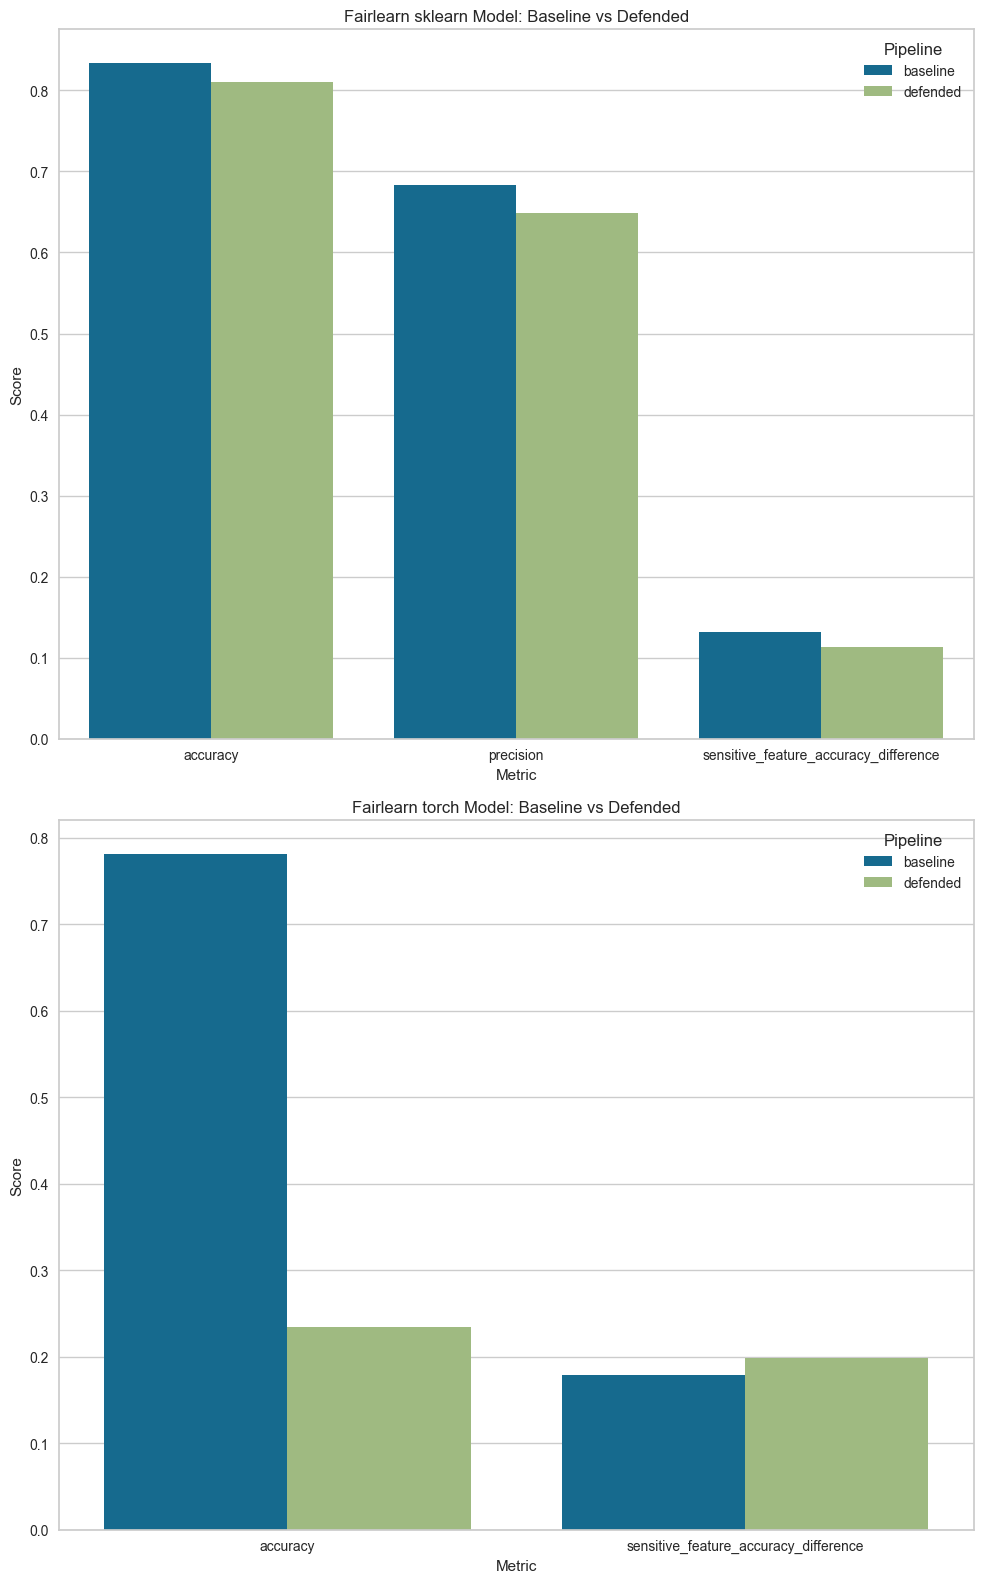

Seaborn comparison plots written: ~/Documents/deckard/notebooks/build/fairlearn_artifacts/plots/fairlearn_sklearn_compare_bar.png ~/Documents/deckard/notebooks/build/fairlearn_artifacts/plots/fairlearn_torch_compare_bar.png

Delta table (defended - baseline):


pipeline,model,metric,baseline,defended,delta_defended_minus_baseline
0,sklearn,accuracy,0.833760,0.810900,-0.022860
1,sklearn,precision,0.682702,0.648558,-0.034144
2,sklearn,sensitive_feature_accuracy_difference,0.132047,0.113280,-0.018767
3,torch,accuracy,0.780900,0.234400,-0.546500
4,torch,sensitive_feature_accuracy_difference,0.179078,0.198358,0.019280


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score


def _group_accuracy_gap(y_true, y_pred, sensitive):
    sensitive_series = pd.Series(sensitive).reset_index(drop=True)
    y_true_series = pd.Series(y_true).reset_index(drop=True)
    y_pred_arr = np.asarray(y_pred).reshape(-1)

    per_group = {}
    for group_value in sorted(sensitive_series.unique().tolist()):
        mask = sensitive_series == group_value
        per_group[f"group_{group_value}_accuracy"] = float(
            accuracy_score(y_true_series.loc[mask], y_pred_arr[mask.to_numpy()]),
        )
    gap = float(max(per_group.values()) - min(per_group.values())) if per_group else np.nan
    return per_group, gap


# Baseline sklearn model on pre-defense Adult features.
base_X_train, base_X_test, base_y_train, base_y_test = train_test_split(
    adult_frame,
    target_series,
    test_size=0.2,
    random_state=42,
    stratify=target_series,
)

baseline_sk_model = LogisticRegression(max_iter=200)
baseline_sk_model.fit(base_X_train, base_y_train)
baseline_sk_pred = baseline_sk_model.predict(base_X_test)

_, baseline_sk_gap = _group_accuracy_gap(
    base_y_test,
    baseline_sk_pred,
    base_X_test["sex"],
)
baseline_sk_scores = {
    "accuracy": float(accuracy_score(base_y_test, baseline_sk_pred)),
    "precision": float(precision_score(base_y_test, baseline_sk_pred, zero_division=0)),
    "sensitive_feature_accuracy_difference": baseline_sk_gap,
}

# Baseline torch model on pre-defense Adult features.
base_X_train_np = base_X_train.to_numpy(dtype=np.float32)
base_X_test_np = base_X_test.to_numpy(dtype=np.float32)
base_y_train_np = base_y_train.to_numpy(dtype=np.int64)
base_y_test_np = base_y_test.to_numpy(dtype=np.int64)

baseline_torch_data = SimpleNamespace(
    X_train=torch.tensor(base_X_train_np, dtype=torch.float32),
    y_train=torch.tensor(base_y_train_np, dtype=torch.long),
    X_test=torch.tensor(base_X_test_np, dtype=torch.float32),
    y_test=torch.tensor(base_y_test_np, dtype=torch.long),
    _sensitive_train=base_X_train["sex"].reset_index(drop=True),
    _sensitive_test=base_X_test["sex"].reset_index(drop=True),
    _sensitive_all=pd.concat(
        [base_X_train["sex"], base_X_test["sex"]],
        ignore_index=True,
    ),
    classifier=True,
)

baseline_torch_model = FairlearnPytorchModelConfig(
    model_type="torch.nn.Linear",
    model_params={"in_features": int(baseline_torch_data.X_train.shape[1]), "out_features": 2},
    classifier=True,
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-3},
    fit_params={"nb_epochs": 2, "batch_size": 128},
    data=baseline_torch_data,
    device="cpu",
)

baseline_torch_scores = baseline_torch_model(baseline_torch_data)
baseline_torch_pred = baseline_torch_model._predict(baseline_torch_data.X_test).argmax(dim=1).cpu().numpy()
_, baseline_torch_gap = _group_accuracy_gap(
    base_y_test_np,
    baseline_torch_pred,
    base_X_test["sex"],
)
baseline_torch_scores["sensitive_feature_accuracy_difference"] = baseline_torch_gap


# ANJANA-style side-by-side comparison table (baseline vs defended).
model_compare = pd.DataFrame(
    [
        {
            "model": "sklearn",
            "metric": "accuracy",
            "value": float(baseline_sk_scores.get("accuracy", np.nan)),
            "pipeline": "baseline",
        },
        {
            "model": "sklearn",
            "metric": "precision",
            "value": float(baseline_sk_scores.get("precision", np.nan)),
            "pipeline": "baseline",
        },
        {
            "model": "sklearn",
            "metric": "sensitive_feature_accuracy_difference",
            "value": float(baseline_sk_scores.get("sensitive_feature_accuracy_difference", np.nan)),
            "pipeline": "baseline",
        },
        {
            "model": "sklearn",
            "metric": "accuracy",
            "value": float(sk_fair_scores.get("accuracy", np.nan)),
            "pipeline": "defended",
        },
        {
            "model": "sklearn",
            "metric": "precision",
            "value": float(sk_fair_scores.get("precision", np.nan)),
            "pipeline": "defended",
        },
        {
            "model": "sklearn",
            "metric": "sensitive_feature_accuracy_difference",
            "value": float(sk_fair_scores.get("sensitive_feature_accuracy_difference", np.nan)),
            "pipeline": "defended",
        },
        {
            "model": "torch",
            "metric": "accuracy",
            "value": float(baseline_torch_scores.get("accuracy", np.nan)),
            "pipeline": "baseline",
        },
        {
            "model": "torch",
            "metric": "sensitive_feature_accuracy_difference",
            "value": float(baseline_torch_scores.get("sensitive_feature_accuracy_difference", np.nan)),
            "pipeline": "baseline",
        },
        {
            "model": "torch",
            "metric": "accuracy",
            "value": float(torch_fair_scores.get("accuracy", np.nan)),
            "pipeline": "defended",
        },
        {
            "model": "torch",
            "metric": "sensitive_feature_accuracy_difference",
            "value": float(torch_fair_scores.get("sensitive_feature_accuracy_difference", np.nan)),
            "pipeline": "defended",
        },
    ],
)

summary_csv = ARTIFACT_DIR / "fairlearn_model_compare.csv"
model_compare.to_csv(summary_csv, index=False)

sklearn_csv = ARTIFACT_DIR / "fairlearn_sklearn_compare.csv"
torch_csv = ARTIFACT_DIR / "fairlearn_torch_compare.csv"

model_compare.loc[model_compare["model"] == "sklearn"].to_csv(sklearn_csv, index=False)
model_compare.loc[model_compare["model"] == "torch"].to_csv(torch_csv, index=False)

sklearn_bar_path = (PLOT_DIR / "fairlearn_sklearn_compare_bar.png").as_posix()
torch_bar_path = (PLOT_DIR / "fairlearn_torch_compare_bar.png").as_posix()

sklearn_bar = SeabornPlotConfig(
    plot_type="bar",
    data_file=sklearn_csv.as_posix(),
    x="metric",
    y="value",
    hue="pipeline",
    title="Fairlearn sklearn Model: Baseline vs Defended",
    xlabel="Metric",
    ylabel="Score",
    legend_title="Pipeline",
    plot_file=sklearn_bar_path,
)

torch_bar = SeabornPlotConfig(
    plot_type="bar",
    data_file=torch_csv.as_posix(),
    x="metric",
    y="value",
    hue="pipeline",
    title="Fairlearn torch Model: Baseline vs Defended",
    xlabel="Metric",
    ylabel="Score",
    legend_title="Pipeline",
    plot_file=torch_bar_path,
)

plot_list = SeabornPlotConfigList(
    data_file=summary_csv.as_posix(),
    plots=[sklearn_bar, torch_bar],
)

_ = plot_list()
plt.show()

delta_df = (
    model_compare
    .pivot_table(index=["model", "metric"], columns="pipeline", values="value")
    .reset_index()
)
delta_df["delta_defended_minus_baseline"] = delta_df["defended"] - delta_df["baseline"]

print("Seaborn comparison plots written:", sklearn_bar_path, torch_bar_path)
print("\nDelta table (defended - baseline):")
delta_df